In [ ]:
!conda install -c conda-forge geopandas rasterio rasterstats folium mapclassify fiona shapely -y

In [4]:
!pip install geopandas rasterio rasterstats folium mapclassify shapely

In [9]:
import geopandas as gpd
# import matplotlib.pyplot as plt
nigeria_path = r"C:\QGIS\Lagos_Flood_Model\01_Raw_Data\geo_boundaries_nga\geoBoundaries-NGA-ADM1.shp"
nigeria = gpd.read_file(nigeria_path)
print(f"✅ Success! Loaded a spatial table with {len(nigeria)} administrative regions.")

# nigeria.head()


✅ Success! Loaded a spatial table with 37 administrative regions.


In [10]:
# 1. Filtering the Nigeria table to extract only the row where shapeName equals Lagos
is_it_lagos = (nigeria['shapeName'] == 'Lagos')
lagos_boundary = nigeria[is_it_lagos]

# print(f"Number of rows found for Lagos: {len(lagos_boundary)}")

# print("\n Lagos Data Column Values:")
# print(lagos_boundary[['shapeName', 'shapeType']])

<Axes: >

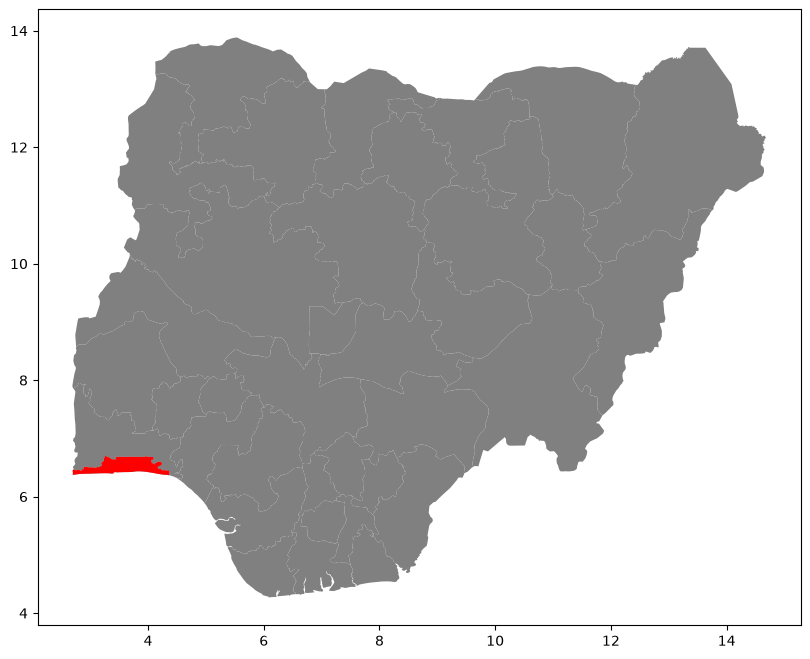

In [11]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(figsize=(10,8))
nigeria.plot(ax=ax,color='gray')
lagos_boundary.plot(ax=ax,color='red')

In [12]:
print("Current Projection:", lagos_boundary.crs)

Current Projection: EPSG:4326


In [13]:
lagos_utm = lagos_boundary.to_crs(epsg=32631)

# 3. Verify that the projection successfully changed
print("New Projected CRS:", lagos_utm.crs)

New Projected CRS: EPSG:32631


In [14]:
# 1. Point to your waterways shapefile path
waterways_path = r"C:\QGIS\Lagos_Flood_Model\01_Raw_Data\hotosm_nga_waterways_osm_shp\waterways_polygons.shp"
waterways = gpd.read_file(waterways_path)
print(f"water: {len(waterways)}")

waterways_utm =  waterways.to_crs(epsg=32631)
waterways_crs =  waterways_utm.crs
print(waterways_crs)

water: 14283
EPSG:32631


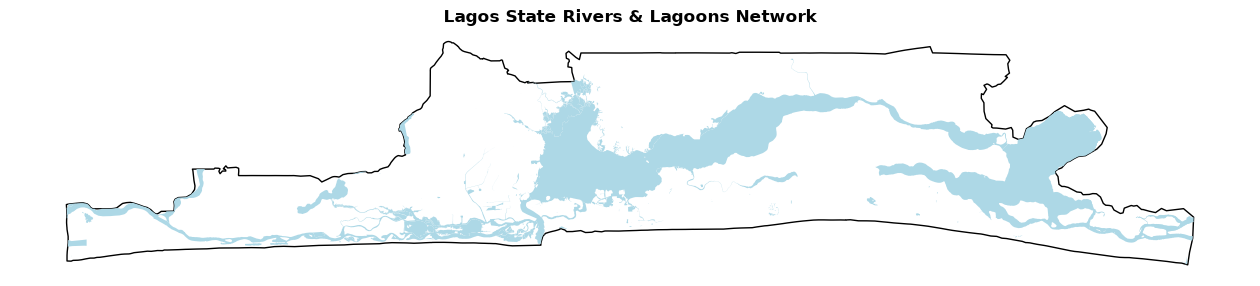

In [15]:
# Clipping the formated lagos and waterways crs. waterways_utm is the target_layer, while lagos_utm is the mask_layer
lagos_waterways =  gpd.clip(waterways_utm, lagos_utm)

# mapping the result
fig, ax = plt.subplots(figsize=(16, 10))

# Lagos boundary outline (no background fill color so we see through it)
lagos_utm.plot(ax=ax, color='none', edgecolor='black', linewidth=1)

# the clipped rivers on top in blue
lagos_waterways.plot(ax=ax, color='lightblue', linewidth=0.8)

plt.title("Lagos State Rivers & Lagoons Network", fontsize=12, fontweight='bold')
ax.set_axis_off()
plt.show()

In [16]:
# Lagos state boundaries
lagos_boundaries = gpd.read_file(r"C:\QGIS\Lagos_Flood_Model\01_Raw_Data\nga_admin_boundaries.shp\nga_admin2.shp")
# print()
lagos_boundaries_utm = lagos_boundaries.to_crs(epsg=32631)
lagos_subdivisions = gpd.clip(lagos_boundaries_utm, lagos_utm)

In [17]:
lga_file_path = r"C:\QGIS\Lagos_Flood_Model\01_Raw_Data\nga_admin_boundaries.shp\nga_admin2.shp"

# 2. Ingest the file using GeoPandas
# print("⌛ Loading all Nigerian LGAs...")
nigeria_lga_map = gpd.read_file(lga_file_path)

# 3. Match the coordinate system to meters
nigeria_lga_utm = nigeria_lga_map.to_crs(epsg=32631)

# 4. Use the Lagos outline shape to cookie-cut only the LGAs inside Lagos bounds
lagos_lgas_only = nigeria_lga_utm[nigeria_lga_utm['adm1_name'] == 'Lagos']

# 2. Extract and print the clean list of unique LGA names
# lga_names = lagos_lgas_only['adm2_name'].unique()


In [18]:
# Define a method for lga labels to avoid usage of code repitition
def add_lga_labels(ax, gdf, name_column='adm2_name', font_size=8, text_color='#222222'):
   
    for index, row in gdf.iterrows():
        # 1. Compute the spatial centroid anchor point
        centroid = row.geometry.centroid
        x, y = centroid.x, centroid.y
        
        # 2. Extract the string name from the specified attribute table column
        label_text = row[name_column]
        
        # 3. Inject the text onto the canvas map layout
        ax.text(
            x, y, 
            s=label_text, 
            fontsize=font_size, 
            fontweight='bold', 
            color=text_color,
            ha='center',     
            va='center',     
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1)
        )
    # print("The method works!")


In [19]:
def add_north_arrow(ax, x=0.06, y=0.72, arrow_length=0.07, size=None):
   
    # Use arrow_length if size is not explicitly passed
    s = size if size is not None else arrow_length
    w = s * 0.35  # Half-width relative to size

    # Left half (Dark Blue)
    left_triangle = plt.Polygon(
        [[x, y + s], [x - w, y], [x, y + s * 0.25]],
        closed=True, facecolor='#2c3e50', edgecolor='#2c3e50',
        transform=ax.transAxes, zorder=20
    )
    # Right half (White/Light highlight)
    right_triangle = plt.Polygon(
        [[x, y + s], [x + w, y], [x, y + s * 0.25]],
        closed=True, facecolor='#ecf0f1', edgecolor='#2c3e50',
        linewidth=0.8, transform=ax.transAxes, zorder=20
    )

    ax.add_patch(left_triangle)
    ax.add_patch(right_triangle)

    # Crisp 'N' placed cleanly above the tip
    ax.text(
        x, y + s + 0.015, 'N',
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=12, fontweight='700',
        color='#2c3e50', zorder=20
    )

def add_scale_bar(ax, length_km=20, location=(0.05, 0.08)):
    """Draws a metric scale bar (valid for UTM Zone 31N coordinates)."""
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Calculate origin in map coordinates based on axes fractions
    x0 = xlim[0] + (xlim[1] - xlim[0]) * location[0]
    y0 = ylim[0] + (ylim[1] - ylim[0]) * location[1]
    length_m = length_km * 1000
    
    # Draw alternating scale segments
    ax.plot([x0, x0 + length_m], [y0, y0], color='#2c3e50', linewidth=3, zorder=10)
    ax.plot([x0, x0 + length_m / 2], [y0, y0], color='white', linewidth=1.5, zorder=11)
    
    # Scale labels
    ax.text(x0, y0 + (ylim[1] - ylim[0]) * 0.015, "0", ha='center', fontsize=8, fontweight='bold', color='#2c3e50', zorder=10)
    ax.text(x0 + length_m, y0 + (ylim[1] - ylim[0]) * 0.015, f"{length_km} km", ha='center', fontsize=8, fontweight='bold', color='#2c3e50', zorder=10)

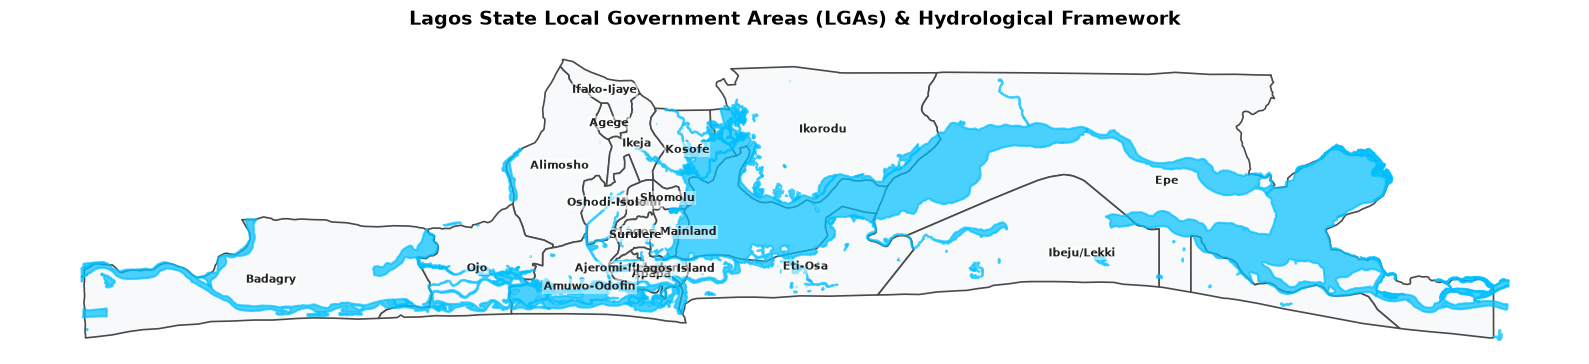

In [20]:
import matplotlib.pyplot as plt

# 1. Create a large, high-resolution canvas
fig, ax = plt.subplots(figsize=(16, 10))

# 2. Plot the clean Lagos LGA shapes
lagos_lgas_only.plot(ax=ax, color='#f7f9fa', edgecolor='#4a4a4a', linewidth=1.2)

# 3. Overlay the water bodies ontop
lagos_waterways.plot(ax=ax, facecolor='deepskyblue', edgecolor='deepskyblue', linewidth=1.5, alpha=0.7)

# 4. loop: Label each LGA 
add_lga_labels(ax=ax, gdf=lagos_lgas_only, name_column='adm2_name')

# 5. Clean up layout aesthetics
plt.title("Lagos State Local Government Areas (LGAs) & Hydrological Framework", fontsize=14, fontweight='bold', pad=15)
ax.set_axis_off()

plt.tight_layout()
plt.show()


Opening raw, unfiltered Copernicus DEM matrix...
Dataset loaded without filters. Generating visualization...


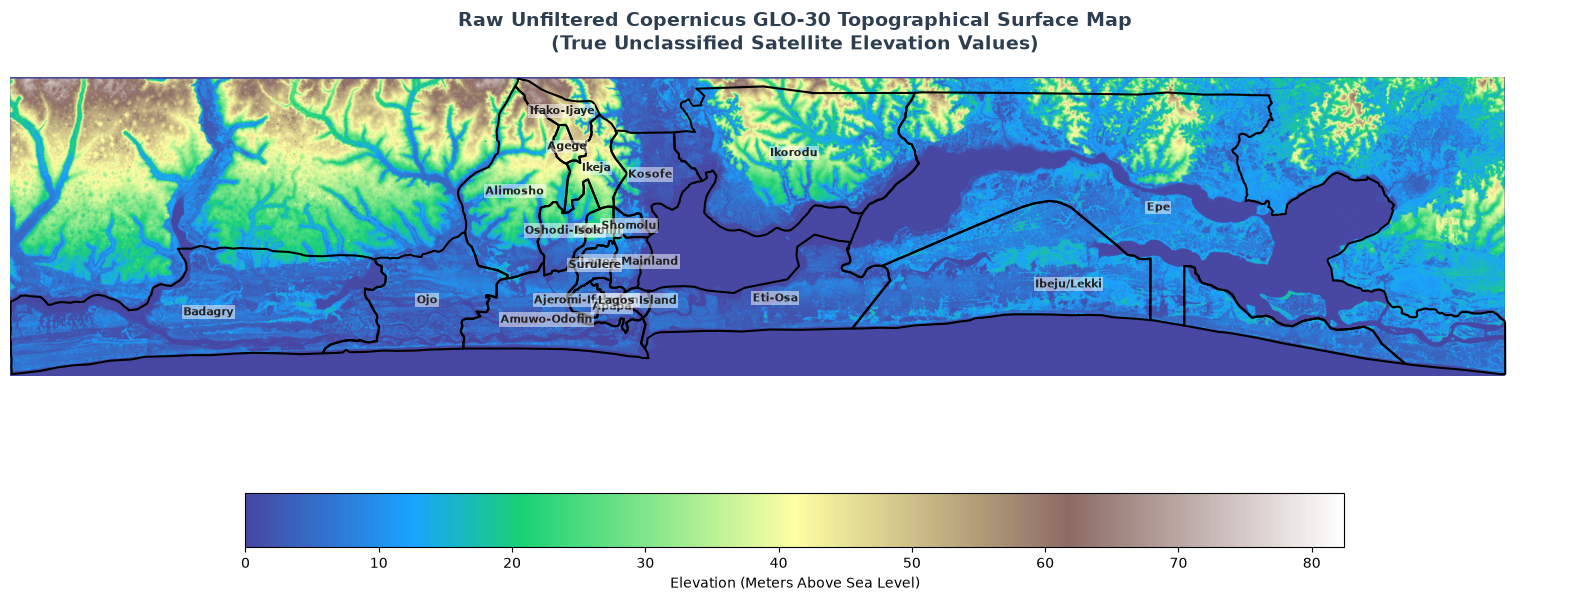

In [21]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# 1. Point to your metric projected Copernicus DEM file path
projected_copernicus_path = r"C:\QGIS\Lagos_Flood_Model\01_Raw_Data\Proccsed_data\Lagos_Copernicus_UTM31N.tif"

print("Opening raw, unfiltered Copernicus DEM matrix...")

with rasterio.open(projected_copernicus_path) as src_raw:
    # Read the raw elevation band into memory
    raw_matrix = src_raw.read(1)
    
    # Force out any background 3D matrix dimensions
    raw_2d_dem = np.squeeze(raw_matrix)
    
    # Extract the exact physical coordinates of the raster image bounds
    raw_extent = [src_raw.bounds.left, src_raw.bounds.right, src_raw.bounds.bottom, src_raw.bounds.top]

print("Dataset loaded without filters. Generating visualization...")

# =====================================================================
# STEP 2: RENDER THE UNCLASSIFIED TOPOGRAPHIC SURFACE IMAGE
# =====================================================================
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_facecolor('#f4f6f7')

# Layer 1: Plot the continuous raw Copernicus elevation values
# 'cmap="terrain"' colors lowlands green, beaches beige, and hills brown/gray
# We mask out extreme negative numbers below -10 to keep the background clean
clean_raw_dem = np.where(raw_2d_dem > -10, raw_2d_dem, np.nan)

im = ax.imshow(
    clean_raw_dem, 
    cmap='terrain', 
    extent=raw_extent, 
    alpha=0.9
)

# Layer 2: Drop your clean true Lagos LGA outlines right on top as hollow shapes
# This lets us verify whether the raster pixels match up with the political lines!
lagos_lgas_only.plot(ax=ax, color='none', edgecolor='black', linewidth=1.5)

# Layer 3: Call your label function to name every LGA for easy orientation
add_lga_labels(ax=ax, gdf=lagos_lgas_only, name_column='adm2_name', font_size=8)

# Map decorations and titles
plt.title("Raw Unfiltered Copernicus GLO-30 Topographical Surface Map\n(True Unclassified Satellite Elevation Values)", 
          fontsize=14, fontweight='bold', pad=20, color='#2c3e50')
plt.colorbar(im, label="Elevation (Meters Above Sea Level)", orientation='horizontal', pad=0.1, shrink=0.7)

ax.set_axis_off()
plt.tight_layout()
plt.show()


Buffer calculation complete! Rendering map...


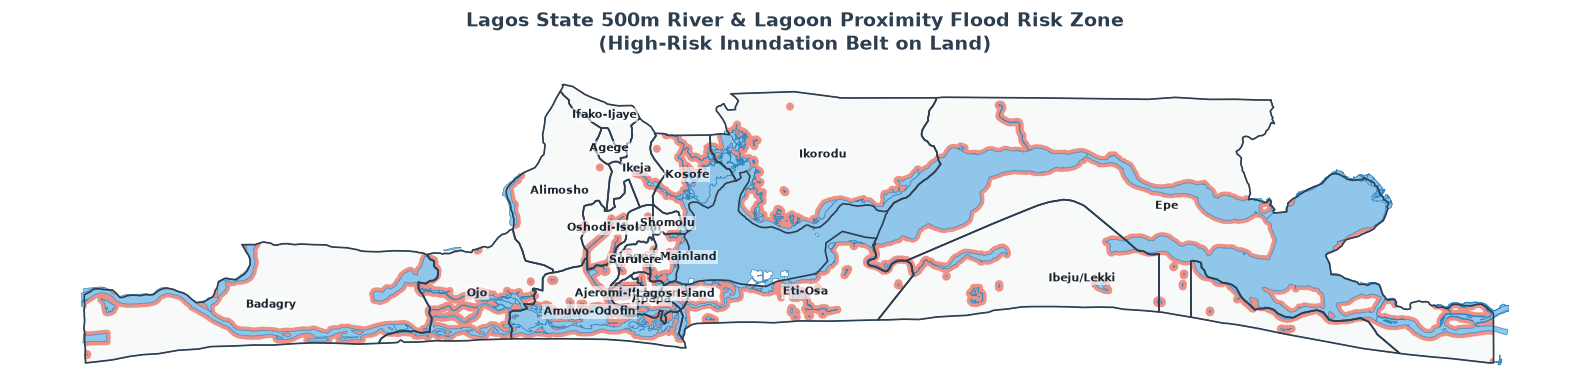

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Ensure waterways match the projected UTM CRS
waterways_utm = lagos_waterways.to_crs(lagos_utm.crs)
lgas_utm = lagos_lgas_only.to_crs(lagos_utm.crs)

# 2. Generate the 500m buffer
river_buffers = waterways_utm.geometry.buffer(500)

# 3. Dissolve overlapping buffer areas
buffer_dissolved = river_buffers.union_all()

# 4. SUBTRACT the water bodies so only dry land within 500m is highlighted
# (Land Risk Fringe = 500m Buffer MINUS Actual Water Surface)
water_dissolved = waterways_utm.geometry.union_all()
land_flood_risk_zone = buffer_dissolved.difference(water_dissolved)

# Clip the risk zone to stay strictly inside Lagos State boundaries
land_flood_risk_zone = land_flood_risk_zone.intersection(lgas_utm.geometry.union_all())

print("Buffer calculation complete! Rendering map...")

# --- RENDER MAP ---
fig, ax = plt.subplots(figsize=(16, 10))

# Layer 1: Lagos State land boundary
lgas_utm.plot(ax=ax, color='#f8f9f9', edgecolor='#7f8c8d', linewidth=0.8, zorder=1)

# Layer 2: 500m Landward Inundation Risk Zone (Only dry land near water)
gpd.GeoSeries([land_flood_risk_zone]).plot(
    ax=ax, 
    color='#e74c3c', 
    alpha=0.6, 
    label='500m Land Flood Risk Zone', 
    zorder=2
)

# Layer 3: Actual Waterways & Lagoons (Filled distinctly in blue)
waterways_utm.plot(
    ax=ax, 
    facecolor='#85c1e9', 
    edgecolor='#2980b9', 
    linewidth=0.5, 
    alpha=0.9, 
    zorder=3
)

# Layer 4: External LGA borders
lgas_utm.plot(ax=ax, color='none', edgecolor='#2c3e50', linewidth=1.2, zorder=4)

# Layer 5: Dynamic LGA Centroid Labels using matched UTM coordinates
for _, row in lgas_utm.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x, centroid.y, 
        s=row['adm2_name'], 
        fontsize=8, 
        fontweight='bold', 
        color='#1a252f',
        ha='center', 
        va='center',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1),
        zorder=5
    )

plt.title("Lagos State 500m River & Lagoon Proximity Flood Risk Zone\n(High-Risk Inundation Belt on Land)", 
          fontsize=14, fontweight='bold', pad=15, color='#2c3e50')

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [30]:
import numpy as np

# slope function
def calculate_slope(dem_array, transform, nodata_val=-10.0):
    # 1. Extract pixel size in meters along X and Y axes
    dx = abs(transform[0])
    dy = abs(transform[4])
    
    # 2. Compute spatial gradients
    grad_y, grad_x = np.gradient(dem_array, dy, dx)
    
    # 3. Calculate slope angle in degrees
    slope_rad = np.arctan(np.sqrt(grad_x**2 + grad_y**2))
    slope_deg = np.degrees(slope_rad)
    
    # 4. Mask out invalid/nodata pixels
    slope_clean = np.where(dem_array > nodata_val, slope_deg, np.nan)
    
    return slope_clean

Masking and cropping Copernicus DEM to Lagos boundaries...
Raster internal NoData value: None
Calculating 500m hydrogeological buffer...
Rendering dual Copernicus DEM & Option A Compound Risk Model...


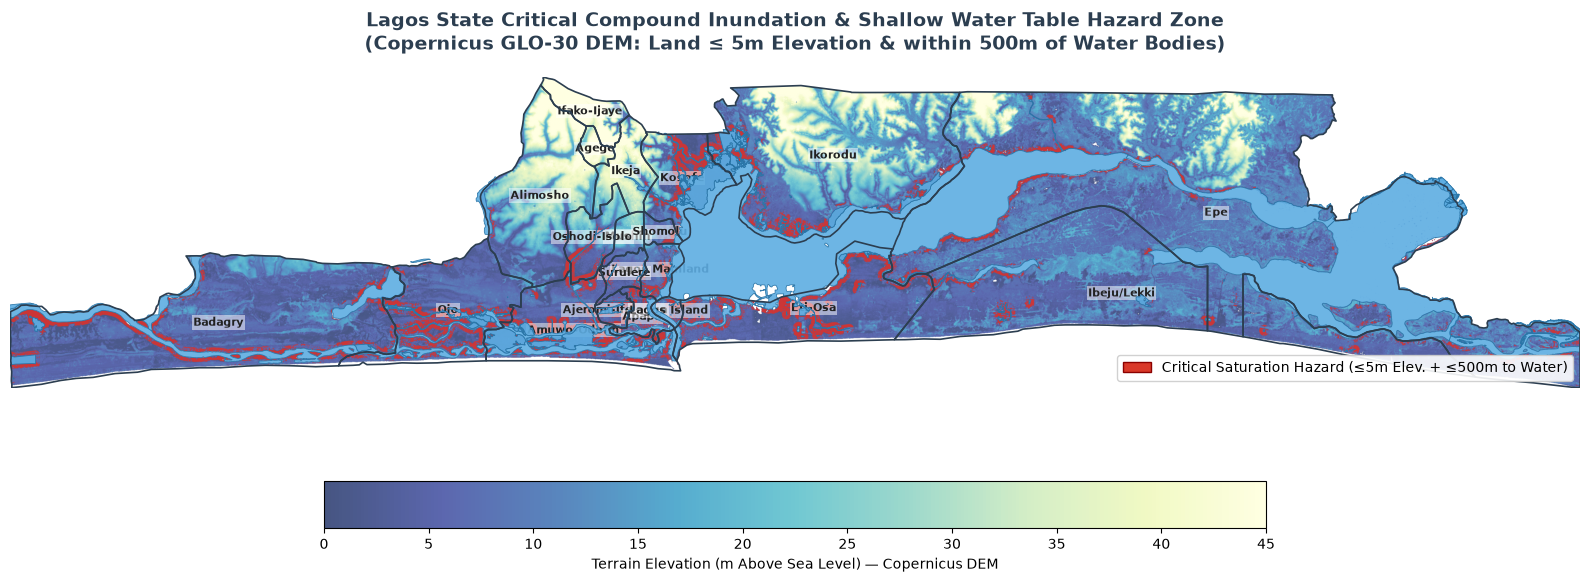

Done! Option A Compound Flood Risk Map successfully generated.


In [31]:
import rasterio
from rasterio.mask import mask
from rasterio.features import geometry_mask
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# 1. Path to your metric projected Copernicus DEM file
projected_copernicus_path = r"C:\QGIS\Lagos_Flood_Model\01_Raw_Data\Proccsed_data\Lagos_Copernicus_UTM31N.tif"

print("Masking and cropping Copernicus DEM to Lagos boundaries...")

with rasterio.open(projected_copernicus_path) as src_raw:
    print("Raster internal NoData value:", src_raw.nodata)
    # Synchronize vector layers to the Copernicus raster CRS (UTM Zone 31N)
    lagos_lgas_proj = lagos_lgas_only.to_crs(src_raw.crs) # or use lgas_utm as it's been converted to crs already, same as lagos_waterways
    lagos_waterways_proj = lagos_waterways.to_crs(src_raw.crs)
    lagos_shapes = [geom for geom in lagos_lgas_proj.geometry] # or # lagos_shapes = []  #for geom in lagos_lgas_proj.geometry:  #lagos_shapes.append(geom)

    # lagos_shapes = []
    #for geom in lagos_lgas_proj.geometry:
    #lagos_shapes.append(geom)

    # Clip Copernicus DEM raster
    clipped_matrix, clipped_transform = mask(
        src_raw,
        lagos_shapes,
        crop=True,
        nodata=-9999
    )

    clipped_dem = clipped_matrix[0]

    h, w = clipped_dem.shape
    xmin = clipped_transform[2]
    ymax = clipped_transform[5]
    xmax = xmin + clipped_transform[0] * w
    ymin = ymax + clipped_transform[4] * h
    clipped_extent = [xmin, xmax, ymin, ymax]

# 2. Elevation processing
clean_clipped_dem = np.where(clipped_dem > -10, clipped_dem, np.nan)
dem_land = np.where(clean_clipped_dem > 0.5, clean_clipped_dem, np.nan)
slope_array = calculate_slope(clean_clipped_dem, clipped_transform, nodata_val=-10.0)

# 3. CALCULATE 500M BUFFER & FILTER ELEVATION <= 5M (OPTION A)
print("Calculating 500m hydrogeological buffer...")
water_footprint = lagos_waterways_proj.geometry.union_all()
buffer_500m = lagos_waterways_proj.geometry.buffer(500).union_all()

# Subtract open water surface to keep only dry land
land_buffer_500m = buffer_500m.difference(water_footprint)
# Confine to Lagos state boundary
land_buffer_500m = land_buffer_500m.intersection(lagos_lgas_proj.geometry.union_all())

# Convert the 500m land buffer polygon into a boolean raster mask
# invert=True means True pixels are INSIDE the 500m buffer zone
buffer_raster_mask = geometry_mask(
    [land_buffer_500m],
    out_shape=(h, w),
    transform=clipped_transform,
    invert=True
)

# OPTION A CONDITION:
# Must be inside 500m buffer AND elevation must be > 0.5m (land) and <= 5.0m (low-lying)
critical_hazard_zone = np.where(
    buffer_raster_mask & (clean_clipped_dem > 0.5) & (clean_clipped_dem <= 5.0) & (slope_array <= 2.0),
    1.0,
    np.nan
)


print("Rendering dual Copernicus DEM & Option A Compound Risk Model...")

# 4. Canvas setup
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_facecolor('#d6eaf8')  # Soft water-blue ocean background

# Layer 1: Copernicus DEM elevation surface
im = ax.imshow(
    dem_land,
    cmap='YlGnBu_r',
    extent=clipped_extent,
    origin='upper',
    vmin=0,
    vmax=45,
    alpha=0.75,
    zorder=2
)

# Layer 2: Option A Compound Hazard Zone (<= 5m elevation AND within 500m of water)
# Strips out all high-elevation ridges in Ikorodu/Kosofe, isolating vulnerable floodplains & barrier islands
ax.imshow(
    critical_hazard_zone,
    cmap='Reds',
    extent=clipped_extent,
    origin='upper',
    vmin=0,
    vmax=1.5,
    alpha=0.85,
    zorder=3
)

# Layer 3: Open Waterways & Lagoons
lagos_waterways_proj.plot(
    ax=ax,
    facecolor='#5dade2',
    edgecolor='#2874a6',
    linewidth=0.6,
    alpha=0.9,
    zorder=4
)

# Layer 4: LGA Boundary Lines
lagos_lgas_proj.plot(
    ax=ax,
    color='none',
    edgecolor='#2c3e50',
    linewidth=1.2,
    zorder=5
)

# Layer 5: Labels
add_lga_labels(ax=ax, gdf=lagos_lgas_proj, name_column='adm2_name', font_size=8)

# Map annotations and styling
plt.title(
    "Lagos State Critical Compound Inundation & Shallow Water Table Hazard Zone\n"
    "(Copernicus GLO-30 DEM: Land ≤ 5m Elevation & within 500m of Water Bodies)",
    fontsize=14,
    fontweight='bold',
    pad=20,
    color='#2c3e50'
)

# Custom legend proxy for the compound risk zone
from matplotlib.patches import Patch
hazard_patch = Patch(facecolor='#d93829', edgecolor='darkred', label='Critical Saturation Hazard (≤5m Elev. + ≤500m to Water)')
ax.legend(handles=[hazard_patch], loc='lower right', framealpha=0.9, fontsize=10)

plt.colorbar(
    im,
    label="Terrain Elevation (m Above Sea Level) — Copernicus DEM",
    orientation='horizontal',
    pad=0.08,
    shrink=0.6
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("Lagos_Copernicus_DEM_OptionA_Compound_Risk.png", dpi=300, bbox_inches='tight')
plt.show()

print("Done! Option A Compound Flood Risk Map successfully generated.")

Masking and cropping Copernicus DEM to Lagos boundaries...
Rendering Pure Elevation Vulnerability Map...


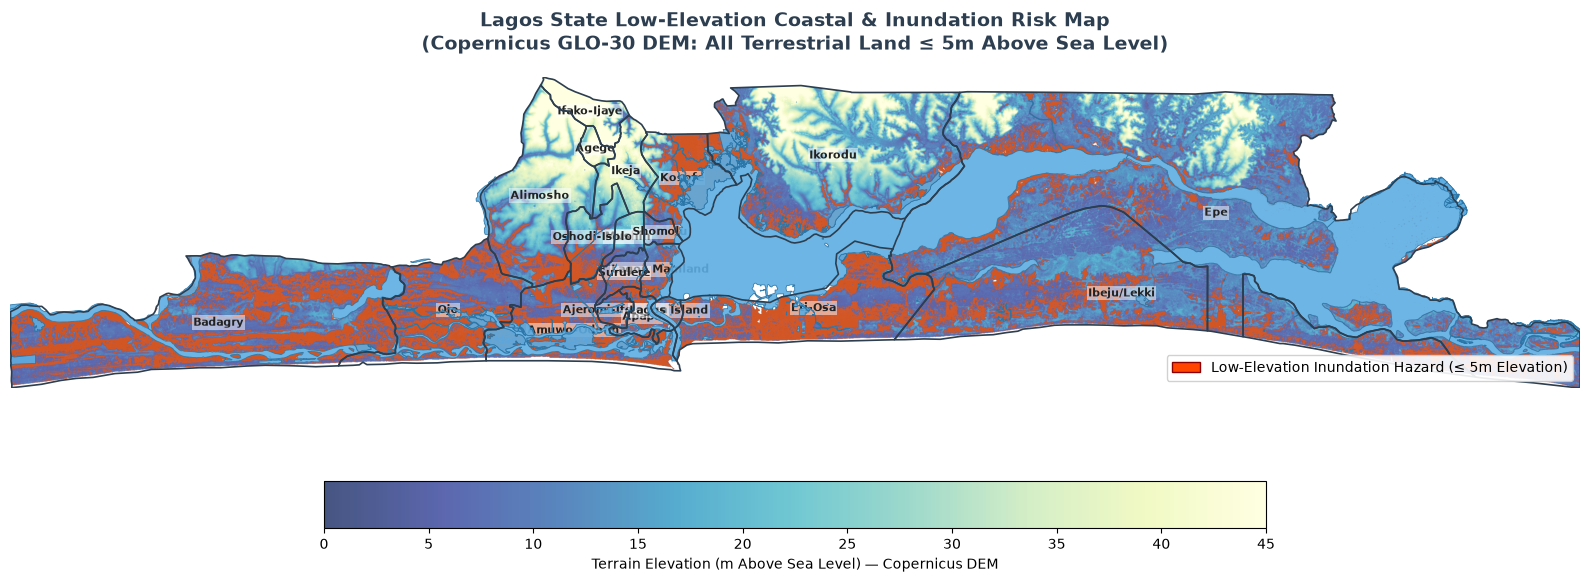

In [24]:
# withiut 500m
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# 1. Path to your metric projected Copernicus DEM file
projected_copernicus_path = r"C:\QGIS\Lagos_Flood_Model\01_Raw_Data\Proccsed_data\Lagos_Copernicus_UTM31N.tif"

print("Masking and cropping Copernicus DEM to Lagos boundaries...")

with rasterio.open(projected_copernicus_path) as src_raw:
    lagos_lgas_proj = lagos_lgas_only.to_crs(src_raw.crs)
    lagos_waterways_proj = lagos_waterways.to_crs(src_raw.crs)
    lagos_shapes = [geom for geom in lagos_lgas_proj.geometry]

    # Clip Copernicus DEM raster
    clipped_matrix, clipped_transform = mask(
        src_raw,
        lagos_shapes,
        crop=True,
        nodata=-9999
    )

    clipped_dem = clipped_matrix[0]
    h, w = clipped_dem.shape
    xmin = clipped_transform[2]
    ymax = clipped_transform[5]
    xmax = xmin + clipped_transform[0] * w
    ymin = ymax + clipped_transform[4] * h
    clipped_extent = [xmin, xmax, ymin, ymax]

# 2. Elevation processing
clean_clipped_dem = np.where(clipped_dem > -10, clipped_dem, np.nan)
dem_land = np.where(clean_clipped_dem > 0.5, clean_clipped_dem, np.nan)
slope_array = calculate_slope(clean_clipped_dem, clipped_transform, nodata_val=-10.0)


# Pure Elevation Threshold: Land <= 5 meters
low_elevation_hazard = np.where((clean_clipped_dem > 0.5) & (clean_clipped_dem <= 5.0) & (slope_array <= 2.0), 1.0, np.nan)

print("Rendering Pure Elevation Vulnerability Map...")

fig, ax = plt.subplots(figsize=(16, 12))
ax.set_facecolor('#d6eaf8')

# Layer 1: Copernicus DEM elevation surface
im = ax.imshow(
    dem_land,
    cmap='YlGnBu_r',
    extent=clipped_extent,
    origin='upper',
    vmin=0,
    vmax=45,
    alpha=0.75,
    zorder=2
)

# Layer 2: All lowlands <= 5m elevation highlighted in bright orange/red
ax.imshow(
    low_elevation_hazard,
    cmap='autumn_r',
    extent=clipped_extent,
    origin='upper',
    vmin=0,
    vmax=1.5,
    alpha=0.75,
    zorder=3
)

# Layer 3: Open Waterways & Lagoons
lagos_waterways_proj.plot(
    ax=ax,
    facecolor='#5dade2',
    edgecolor='#2874a6',
    linewidth=0.6,
    alpha=0.9,
    zorder=4
)

# Layer 4: LGA Boundaries & Labels
lagos_lgas_proj.plot(ax=ax, color='none', edgecolor='#2c3e50', linewidth=1.2, zorder=5)
add_lga_labels(ax=ax, gdf=lagos_lgas_proj, name_column='adm2_name', font_size=8)

plt.title(
    "Lagos State Low-Elevation Coastal & Inundation Risk Map\n"
    "(Copernicus GLO-30 DEM: All Terrestrial Land ≤ 5m Above Sea Level)",
    fontsize=14,
    fontweight='bold',
    pad=20,
    color='#2c3e50'
)

hazard_patch = Patch(facecolor='#ff4500', edgecolor='darkred', label='Low-Elevation Inundation Hazard (≤ 5m Elevation)')
ax.legend(handles=[hazard_patch], loc='lower right', framealpha=0.9, fontsize=10)

plt.colorbar(
    im,
    label="Terrain Elevation (m Above Sea Level) — Copernicus DEM",
    orientation='horizontal',
    pad=0.08,
    shrink=0.6
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("Lagos_Copernicus_DEM_Pure_Elevation_5m.png", dpi=300, bbox_inches='tight')
plt.show()

Computing 500m hydrogeological saturation fringe...
Rendering 500m Hydrogeological Saturation Zone Map...


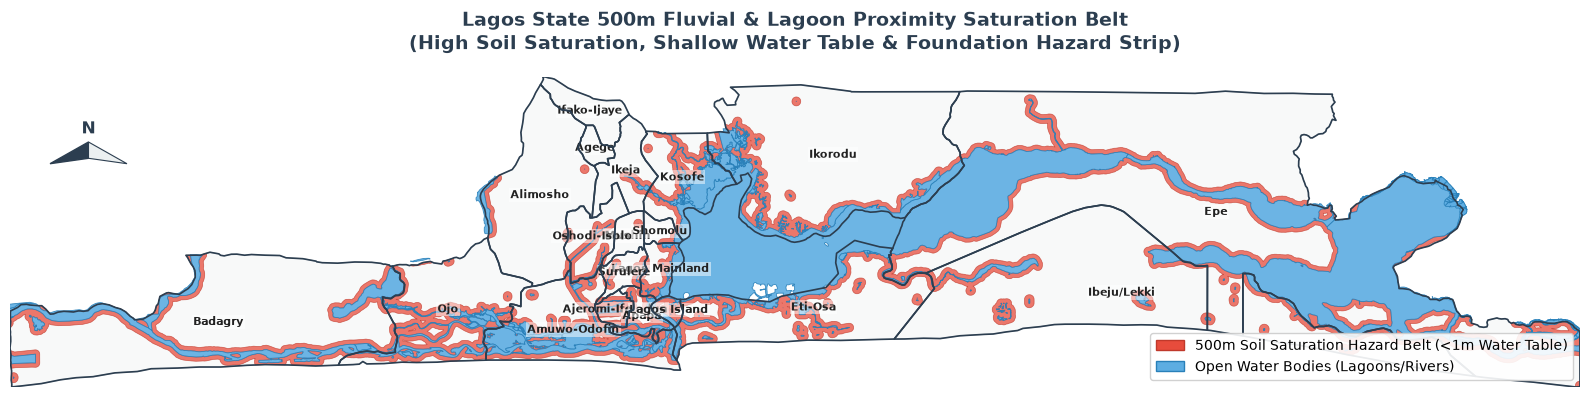

In [27]:
# just 500 m
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. Project layers into UTM Zone 31N (Metric projection for accurate 500m measurement)
target_crs = "EPSG:32631"
lagos_lgas_utm = lagos_lgas_only.to_crs(target_crs)
lagos_waterways_utm = lagos_waterways.to_crs(target_crs)

print("Computing 500m hydrogeological saturation fringe...")

# 2. Extract landward 500m buffer
water_footprint = lagos_waterways_utm.geometry.union_all()
raw_buffer_500m = lagos_waterways_utm.geometry.buffer(500).union_all()

# Subtract the water bodies so only dry land within 500m is highlighted
landward_saturation_500m = raw_buffer_500m.difference(water_footprint)

# Clip boundary strictly to Lagos State administrative boundaries
landward_saturation_500m = landward_saturation_500m.intersection(lagos_lgas_utm.geometry.union_all())

print("Rendering 500m Hydrogeological Saturation Zone Map...")

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_facecolor('#eef2f3')

# Layer 1: Base Lagos LGA Land Area
lagos_lgas_utm.plot(
    ax=ax,
    color='#f8f9f9',
    edgecolor='#bdc3c7',
    linewidth=0.8,
    zorder=1
)

# Layer 2: 500m Subsurface Saturation Hazard Belt on Dry Land
gpd.GeoSeries([landward_saturation_500m]).plot(
    ax=ax,
    facecolor='#e74c3c',
    edgecolor='#c0392b',
    linewidth=0.5,
    alpha=0.75,
    zorder=2
)

# Layer 3: Open Waterways & Lagoons
lagos_waterways_utm.plot(
    ax=ax,
    facecolor='#5dade2',
    edgecolor='#2980b9',
    linewidth=0.6,
    alpha=0.9,
    zorder=3
)

# Layer 4: Clear LGA outlines & Labels
lagos_lgas_utm.plot(ax=ax, color='none', edgecolor='#2c3e50', linewidth=1.2, zorder=4)
add_lga_labels(ax=ax, gdf=lagos_lgas_utm, name_column='adm2_name', font_size=8)
add_north_arrow(ax, x=0.05, y=0.72, arrow_length=0.07)
# add_scale_bar(ax, length_km=20, location=(0.05, 0.08))
plt.title(
    "Lagos State 500m Fluvial & Lagoon Proximity Saturation Belt\n"
    "(High Soil Saturation, Shallow Water Table & Foundation Hazard Strip)",
    fontsize=14,
    fontweight='bold',
    pad=20,
    color='#2c3e50'
)

legend_water = Patch(facecolor='#5dade2', edgecolor='#2980b9', label='Open Water Bodies (Lagoons/Rivers)')
legend_buffer = Patch(facecolor='#e74c3c', edgecolor='#c0392b', label='500m Soil Saturation Hazard Belt (<1m Water Table)')
ax.legend(handles=[legend_buffer, legend_water], loc='lower right', framealpha=0.9, fontsize=10)

minx, miny, maxx, maxy = lagos_lgas_utm.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("Lagos_500m_Hydrogeological_Saturation_Belt.png", dpi=300, bbox_inches='tight')
plt.show()